In [1]:
import sys
!{sys.executable} -m pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
print("loading the data")
df = pd.read_csv("sero_features_4.csv")

loading the data


In [108]:
df.head()

,Target,AccMeanX,AccMeanY,AccMeanZ,AccCovX,AccCovY,AccCovZ,AccSkewX,AccSkewY,AccSkewZ,...,GyroMaxZ,GyroVarX,GyroVarY,GyroVarZ,GyroMedianX,GyroMedianY,GyroMedianZ,GyroStdX,GyroStdY,GyroStdZ
0,1,0.285339,-0.138611,-0.957764,0.022150,0.003975,0.001926,0.867594,-1.305868,-0.507254,...,0.832061,0.761120,0.184372,0.262859,-0.286260,4.251908,0.706107,0.872422,0.429385,0.512697
1,1,0.313477,-0.161670,-0.956250,0.020571,0.005640,0.001456,0.002474,-0.395088,-0.677572,...,0.832061,3.061080,0.585991,0.270340,0.335878,3.969466,0.587786,1.749594,0.765501,0.519942
2,1,0.325195,-0.158325,-0.950155,0.017281,0.004579,0.001388,-0.354212,-0.603657,-0.984635,...,0.832061,3.137076,0.552431,0.905518,-0.286260,3.832061,0.240458,1.771179,0.743257,0.951587
3,1,0.336565,-0.172468,-0.937640,0.015305,0.005216,0.002253,-0.655653,-0.152454,-0.040530,...,0.832061,2.809524,3.963056,0.893127,0.335878,3.969466,-0.106870,1.676163,1.990743,0.945054
4,1,0.337860,-0.164185,-0.941681,0.013132,0.005020,0.002062,-0.718488,-0.446061,0.250539,...,0.832061,2.667567,3.414394,0.799787,-0.286260,4.038168,-0.179389,1.633269,1.847808,0.894308


In [109]:
missing_values = df.isnull().sum().sum()
print(missing_values)

0


In [110]:
df=df.drop_duplicates()

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1102 entries, 0 to 1101
Data columns (total 61 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Target       1102 non-null   int64  
 1   AccMeanX     1102 non-null   float64
 2   AccMeanY     1102 non-null   float64
 3   AccMeanZ     1102 non-null   float64
 4   AccCovX      1102 non-null   float64
 5   AccCovY      1102 non-null   float64
 6   AccCovZ      1102 non-null   float64
 7   AccSkewX     1102 non-null   float64
 8   AccSkewY     1102 non-null   float64
 9   AccSkewZ     1102 non-null   float64
 10  AccKurtX     1102 non-null   float64
 11  AccKurtY     1102 non-null   float64
 12  AccKurtZ     1102 non-null   float64
 13  AccSumX      1102 non-null   float64
 14  AccSumY      1102 non-null   float64
 15  AccSumZ      1102 non-null   float64
 16  AccMinX      1102 non-null   float64
 17  AccMinY      1102 non-null   float64
 18  AccMinZ      1102 non-null   float64
 19  AccMax

In [112]:
df.describe()

,Target,AccMeanX,AccMeanY,AccMeanZ,AccCovX,AccCovY,AccCovZ,AccSkewX,AccSkewY,AccSkewZ,...,GyroMaxZ,GyroVarX,GyroVarY,GyroVarZ,GyroMedianX,GyroMedianY,GyroMedianZ,GyroStdX,GyroStdY,GyroStdZ
count,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,...,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000
mean,2.490018,0.250681,-0.094582,-0.983306,0.029196,0.030323,0.009583,-0.112822,-0.099898,-0.186448,...,13.362845,11.155935,10.381491,114.428756,-0.735789,4.211808,1.109295,3.142812,3.034641,8.206899
std,1.050665,0.080183,0.091875,0.026849,0.022935,0.022036,0.006485,0.698375,1.056449,0.892163,...,16.113840,7.374181,7.085781,115.341708,0.844474,0.844673,1.514056,1.131295,1.083287,6.864279
min,1.000000,0.019642,-0.309535,-1.053659,0.000042,0.000070,0.000118,-2.694572,-3.429108,-3.073868,...,0.832061,0.053027,0.030970,0.026300,-4.061069,-0.736641,-15.675573,0.230276,0.175983,0.162173
25%,2.000000,0.196429,-0.166037,-1.003257,0.012777,0.007605,0.004619,-0.558205,-0.866926,-0.781039,...,2.389313,5.376291,5.239952,1.246986,-1.084924,3.779580,0.759542,2.318683,2.289094,1.116685
50%,3.000000,0.254752,-0.114406,-0.984262,0.022769,0.031239,0.008100,-0.135493,-0.123392,-0.124783,...,4.625954,9.686863,8.728437,127.534036,-0.660305,4.297710,1.019084,3.112373,2.954393,11.293095
75%,3.000000,0.309457,-0.007616,-0.964587,0.034529,0.045968,0.012561,0.205514,0.774952,0.350263,...,32.601145,14.986955,13.725827,217.342978,-0.347328,4.747137,1.427481,3.871299,3.704838,14.742556
max,4.000000,0.445452,0.114851,-0.900652,0.109354,0.094144,0.030886,3.321394,2.504595,3.356136,...,45.442748,39.778734,35.373877,379.616823,3.358779,6.500000,9.721374,6.307038,5.947594,19.483758


In [113]:
# there isnot missing value
#there isnot categorical data
# we donot remove outlier because it is important




class_names = {
    1: 'Sudden Acceleration',
    2: 'Sudden Right Turn',
    3: 'Sudden Left Turn',
    4: 'Sudden Break'
}
df['Behavior_Name'] = df['Target'].map(class_names)

In [114]:
df['AccTotalMagnitude'] = np.sqrt(df['AccMeanX']**2 + df['AccMeanY']**2 + df['AccMeanZ']**2)


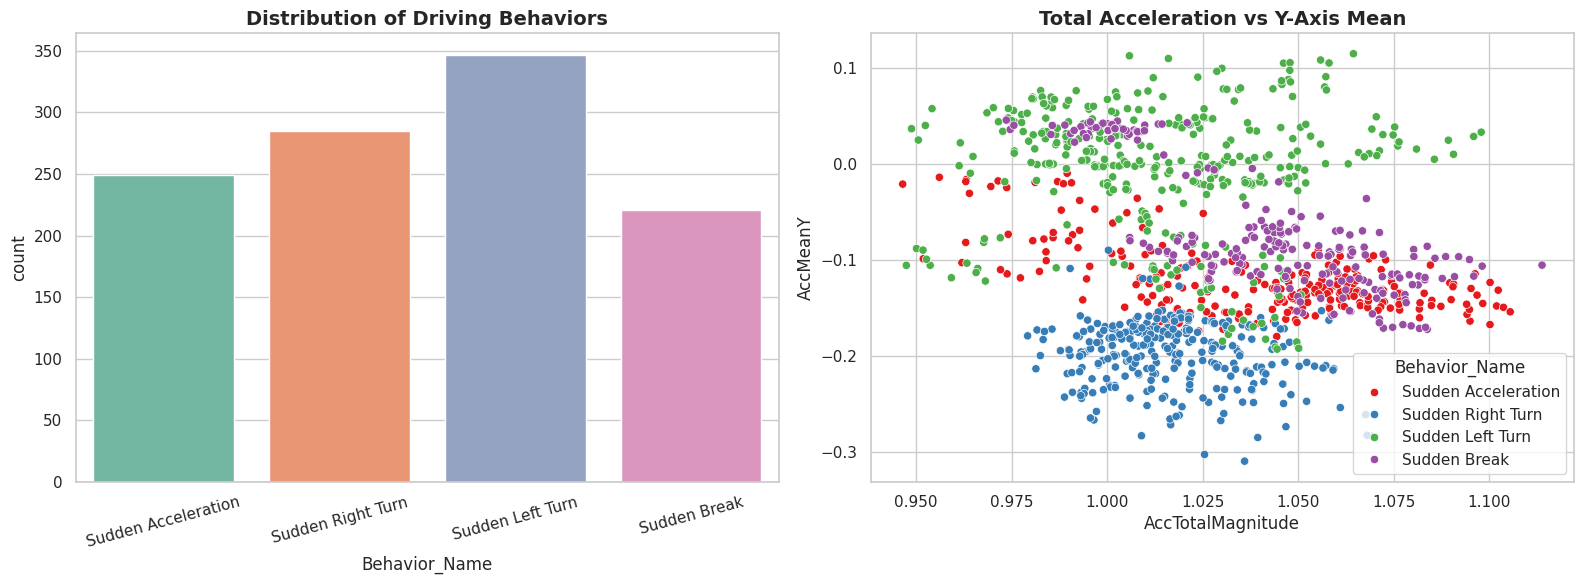

In [115]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Behavior_Name', palette='Set2', ax=axes[0])
axes[0].set_title('Distribution of Driving Behaviors', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)


sns.scatterplot(data=df, x='AccTotalMagnitude', y='AccMeanY', hue='Behavior_Name', palette='Set1', ax=axes[1])
axes[1].set_title('Total Acceleration vs Y-Axis Mean', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [116]:
X = df.drop(columns=['Target', 'Behavior_Name'])

y = df['Target'] - 1

In [117]:
print(y.value_counts().sort_index())

Target
0    249
1    285
2    347
3    221
Name: count, dtype: int64


In [118]:
#the target is balanced

train_indices = []
test_indices = []

# (No Data Leakage)
for class_label in y.unique():
    class_idx = df[y == class_label].index.tolist()
    split_point = int(len(class_idx) * 0.80) # 80%
    train_indices.extend(class_idx[:split_point])
    test_indices.extend(class_idx[split_point:])

In [119]:
X_train, X_test = X.loc[train_indices], X.loc[test_indices]
y_train, y_test = y.loc[train_indices], y.loc[test_indices]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:
print("training the model")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVC (Support Vector)': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1, eval_metric='mlogloss')
}

results = {}
best_model_name = ""
best_accuracy = 0
best_y_pred = None

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc * 100

    print(f" {name:20} -> Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred))

    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_y_pred = y_pred

training the model
 Logistic Regression  -> Accuracy: 68.92%
              precision    recall  f1-score   support

           0       0.42      0.84      0.56        50
           1       0.90      0.93      0.91        57
           2       0.93      0.19      0.31        70
           3       0.90      1.00      0.95        45

    accuracy                           0.69       222
   macro avg       0.79      0.74      0.68       222
weighted avg       0.80      0.69      0.65       222

 KNN                  -> Accuracy: 70.27%
              precision    recall  f1-score   support

           0       0.45      0.86      0.59        50
           1       1.00      0.96      0.98        57
           2       0.65      0.19      0.29        70
           3       0.87      1.00      0.93        45

    accuracy                           0.70       222
   macro avg       0.74      0.75      0.70       222
weighted avg       0.74      0.70      0.66       222

 SVC (Support Vector) -> Ac

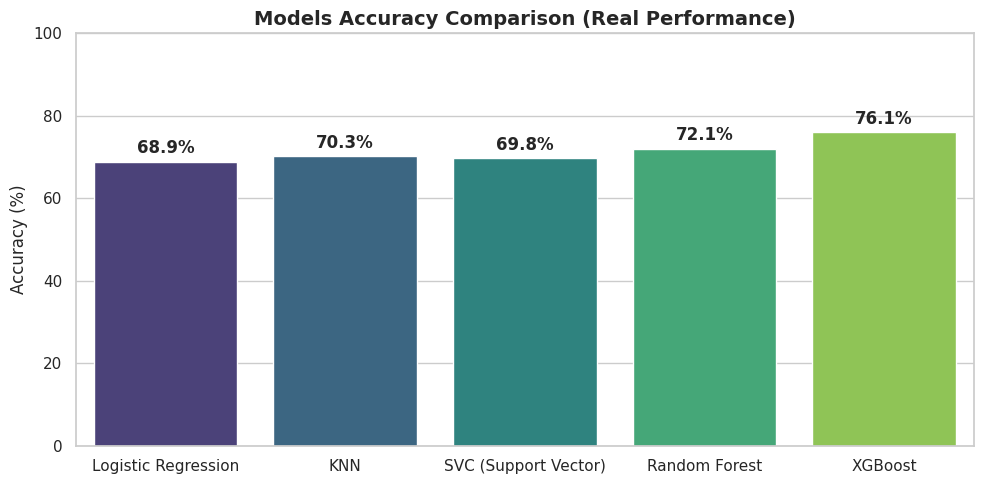

In [121]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Models Accuracy Comparison (Real Performance)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
for i, v in enumerate(results.values()):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [122]:
print(f"\n The best model is {best_model_name} بدقة {best_accuracy * 100:.2f}%\n")

ordered_class_names = [class_names[1], class_names[2], class_names[3], class_names[4]]

print("(Classification Report):")
print(classification_report(y_test, best_y_pred, target_names=ordered_class_names))



 The best model is XGBoost بدقة 76.13%

(Classification Report):
                     precision    recall  f1-score   support

Sudden Acceleration       0.48      0.88      0.62        50
  Sudden Right Turn       1.00      1.00      1.00        57
   Sudden Left Turn       0.96      0.33      0.49        70
       Sudden Break       0.90      1.00      0.95        45

           accuracy                           0.76       222
          macro avg       0.84      0.80      0.77       222
       weighted avg       0.85      0.76      0.74       222



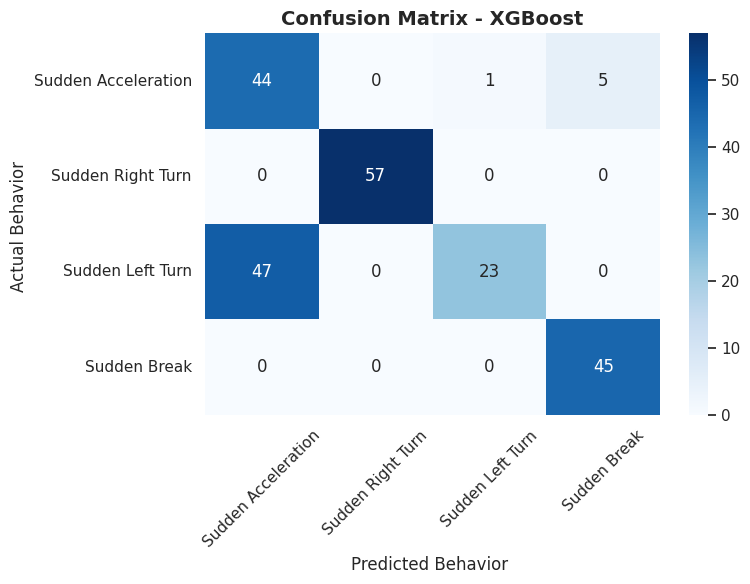

In [123]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordered_class_names, yticklabels=ordered_class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Behavior ', fontsize=12)
plt.ylabel('Actual Behavior ', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

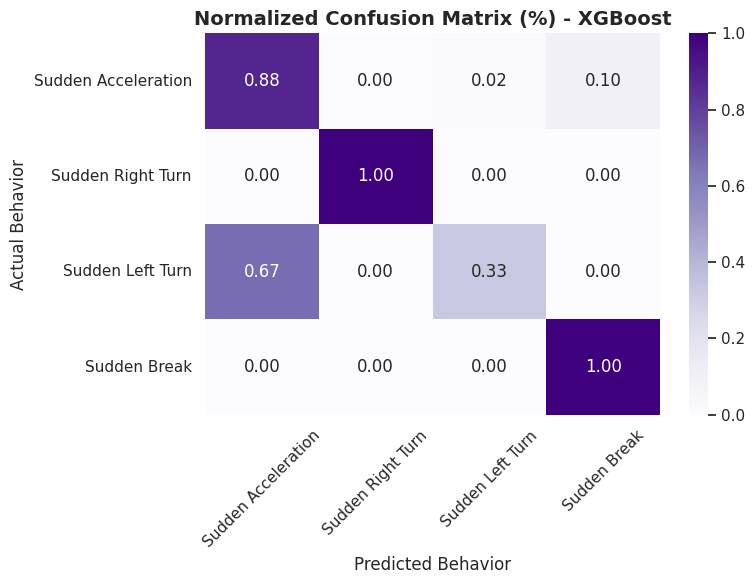

In [124]:
plt.figure(figsize=(8, 6))
cm_normalized = confusion_matrix(y_test, best_y_pred, normalize='true')
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=ordered_class_names, yticklabels=ordered_class_names)
plt.title(f'Normalized Confusion Matrix (%) - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Behavior', fontsize=12)
plt.ylabel('Actual Behavior', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

the best feature


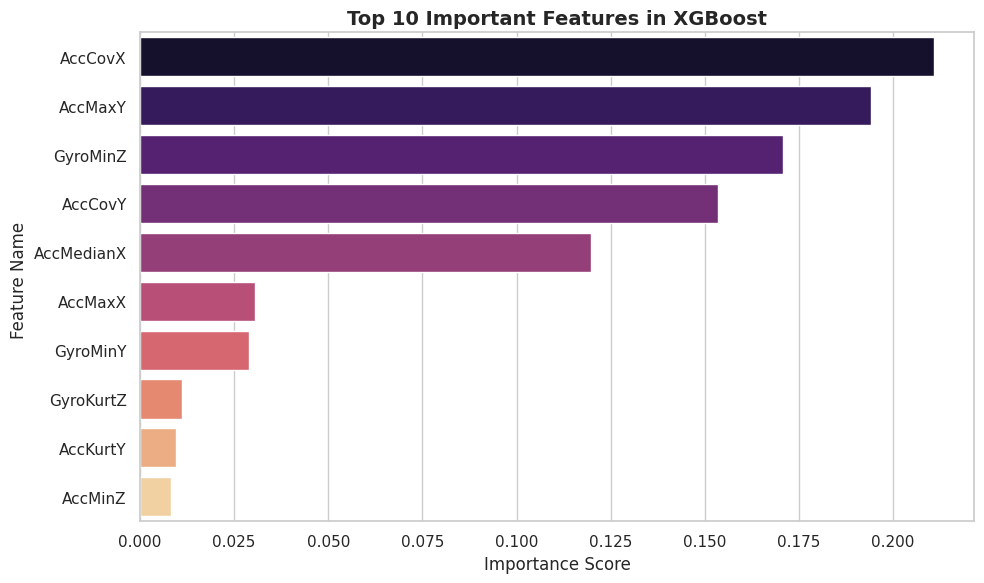

In [125]:

print("the best feature")
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):

    importances = best_model.feature_importances_
    feature_names = X.columns

    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)


    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='magma')
    plt.title(f'Top 10 Important Features in {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature Name ', fontsize=12)
    plt.tight_layout()
    plt.show()

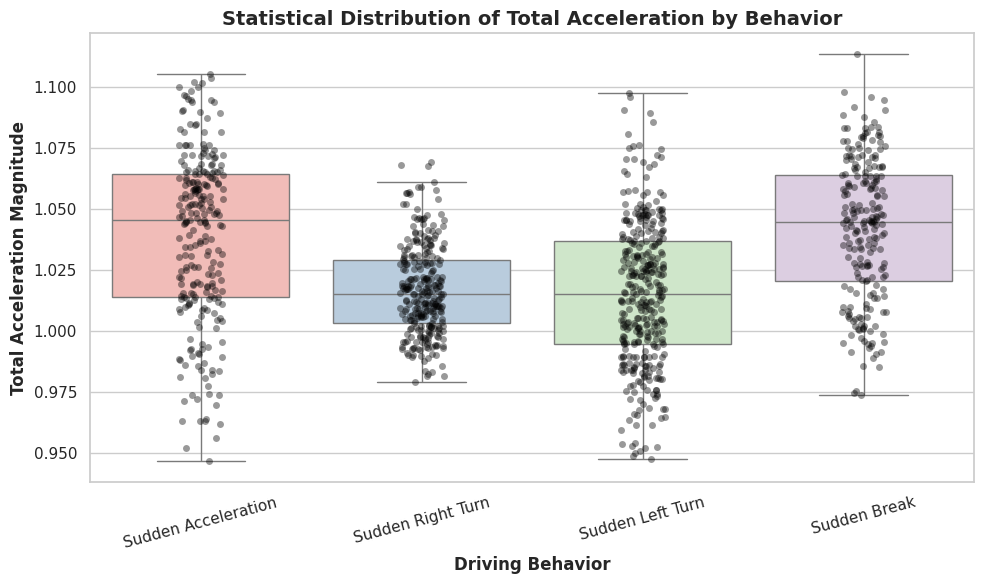

In [126]:


plt.figure(figsize=(10, 6))


sns.boxplot(data=df, x='Behavior_Name', y='AccTotalMagnitude', palette='Pastel1', showfliers=False)


sns.stripplot(data=df, x='Behavior_Name', y='AccTotalMagnitude', color='black', alpha=0.4, jitter=True)


plt.title('Statistical Distribution of Total Acceleration by Behavior', fontsize=14, fontweight='bold')
plt.xlabel('Driving Behavior', fontsize=12, fontweight='bold')
plt.ylabel('Total Acceleration Magnitude', fontsize=12, fontweight='bold')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
# Export trained artifacts for the GUI (run this cell after training)
import json
from pathlib import Path

import joblib
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

project_dir = Path.cwd()

original_features = [c for c in df.columns if c not in ['Target', 'Behavior_Name', 'AccTotalMagnitude']]
engineered_features = ['AccTotalMagnitude']
final_features = X.columns.tolist()

def _safe_params(model):
    try:
        params = model.get_params()
    except Exception:
        return {}
    keep = [
        'max_iter', 'random_state', 'n_neighbors', 'kernel',
        'n_estimators', 'n_jobs', 'learning_rate', 'max_depth',
        'eval_metric', 'C', 'probability'
    ]
    return {k: params[k] for k in keep if k in params}

def _roc_auc(model, X_scaled, y_true):
    if not hasattr(model, 'predict_proba'):
        return None
    try:
        proba = model.predict_proba(X_scaled)
        return float(roc_auc_score(y_true, proba, multi_class='ovr', average='macro'))
    except Exception:
        return None

results_by_model = {}
for name, model in models.items():
    y_pred_m = model.predict(X_test_scaled)
    report_m = classification_report(
        y_test, y_pred_m, target_names=ordered_class_names, output_dict=True, zero_division=0
    )
    results_by_model[name] = {
        'model_type': type(model).__name__,
        'parameters': _safe_params(model),
        'accuracy': float(accuracy_score(y_test, y_pred_m)),
        'precision': float(precision_score(y_test, y_pred_m, average='macro', zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_m, average='macro', zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_m, average='macro', zero_division=0)),
        'roc_auc': _roc_auc(model, X_test_scaled, y_test),
        'classification_report': report_m,
        'confusion_matrix': confusion_matrix(y_test, y_pred_m).tolist(),
    }

feature_stats = {
    col: {
        'min': float(X[col].min()),
        'max': float(X[col].max()),
        'mean': float(X[col].mean()),
        'median': float(X[col].median()),
        'dtype': 'numeric',
    }
    for col in final_features
}

export_payload = {
    'best_model_name': best_model_name,
    'best_accuracy': float(best_accuracy),
    'results_by_model': results_by_model,
    'classification_report': classification_report(
        y_test, best_y_pred, target_names=ordered_class_names, output_dict=True, zero_division=0
    ),
    'confusion_matrix': confusion_matrix(y_test, best_y_pred).tolist(),
    'normalized_confusion_matrix': confusion_matrix(y_test, best_y_pred, normalize='true').tolist(),
    'target_names': ordered_class_names,
    'class_names': class_names,
    'label_offset': 1,
    'target_distribution': df['Target'].value_counts().sort_index().to_dict(),
    'preprocessing_steps': {
        'missing_values': 'Checked missing values; none were found, so no imputation was applied.',
        'duplicates': 'Duplicate rows were dropped with drop_duplicates().',
        'encoding': 'No categorical encoding was used. Behavior_Name is a display label only and was dropped before training.',
        'scaling': 'StandardScaler was fit on the training features and applied to train and test sets.',
        'outlier_handling': 'Outliers were not removed because they are considered important for this behavior data.',
        'train_test_split': 'Per-class 80/20 split using index grouping to avoid shuffling leakage (no sklearn train_test_split).',
        'smote': 'SMOTE was not used. The notebook notes that the target is balanced.',
        'label_mapping': 'Target labels were shifted by -1 for model training (1-4 became 0-3).',
    },
    'original_features': original_features,
    'engineered_features': engineered_features,
    'selected_features': final_features,
    'feature_names': final_features,
    'feature_stats': feature_stats,
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
}

df.to_csv(project_dir / 'dataset.csv', index=False)
joblib.dump(models[best_model_name], project_dir / 'model.pkl')
joblib.dump(scaler, project_dir / 'preprocessor.pkl')
joblib.dump(models, project_dir / 'all_models.pkl')
joblib.dump(export_payload, project_dir / 'evaluation_results.pkl')

metadata = {
    'project_title': 'Driving Behavior Classification',
    'project_description': (
        'Classifies driving maneuvers from smartphone accelerometer and gyroscope '
        'statistics. The target classes are Sudden Acceleration, Sudden Right Turn, '
        'Sudden Left Turn, and Sudden Break.'
    ),
    'problem_type': 'Multiclass Classification',
    'target_variable': 'Target',
    'target_names': ordered_class_names,
    'class_names': {str(k): v for k, v in class_names.items()},
    'n_samples': int(len(df)),
    'n_features': int(len(final_features)),
    'feature_names': final_features,
    'original_features': original_features,
    'engineered_features': engineered_features,
    'selected_features': final_features,
    'dataset_shape': [int(df.shape[0]), int(df.shape[1])],
    'best_model_name': best_model_name,
    'best_model_type': type(models[best_model_name]).__name__,
    'preprocessing_steps': export_payload['preprocessing_steps'],
    'source_file': 'sero_features_4.csv',
}
with open(project_dir / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Artifacts exported to:', project_dir)
print('Saved: dataset.csv, model.pkl, preprocessor.pkl, all_models.pkl, evaluation_results.pkl, metadata.json')
